In [6]:
# Importation des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Chargement du dataset
file_path = "../data/global_energy_consumption.csv" 
df = pd.read_csv(file_path)

In [8]:
# Affichage des 5 premières lignes
print("Aperçu des premières lignes du dataset :")
print(df.head())

Aperçu des premières lignes du dataset :
   Country  Year  Total Energy Consumption (TWh)  Per Capita Energy Use (kWh)  \
0   Canada  2018                         9525.38                     42301.43   
1  Germany  2020                         7922.08                     36601.38   
2   Russia  2002                         6630.01                     41670.20   
3   Brazil  2010                         8580.19                     10969.58   
4   Canada  2006                          848.88                     32190.85   

   Renewable Energy Share (%)  Fossil Fuel Dependency (%)  \
0                       13.70                       70.47   
1                       33.63                       41.95   
2                       10.82                       39.32   
3                       73.24                       16.71   
4                       73.60                       74.86   

   Industrial Energy Use (%)  Household Energy Use (%)  \
0                      45.18                   

In [9]:
# Affichage des informations générales sur le dataset
print("\nInformations générales sur les données :")
print(df.info())


Informations générales sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          10000 non-null  object 
 1   Year                             10000 non-null  int64  
 2   Total Energy Consumption (TWh)   10000 non-null  float64
 3   Per Capita Energy Use (kWh)      10000 non-null  float64
 4   Renewable Energy Share (%)       10000 non-null  float64
 5   Fossil Fuel Dependency (%)       10000 non-null  float64
 6   Industrial Energy Use (%)        10000 non-null  float64
 7   Household Energy Use (%)         10000 non-null  float64
 8   Carbon Emissions (Million Tons)  10000 non-null  float64
 9   Energy Price Index (USD/kWh)     10000 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 781.4+ KB
None


In [10]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
Country                            0
Year                               0
Total Energy Consumption (TWh)     0
Per Capita Energy Use (kWh)        0
Renewable Energy Share (%)         0
Fossil Fuel Dependency (%)         0
Industrial Energy Use (%)          0
Household Energy Use (%)           0
Carbon Emissions (Million Tons)    0
Energy Price Index (USD/kWh)       0
dtype: int64


In [11]:
# Configuration du style des graphiques
sns.set_style('white')
plt.style.use("dark_background")

# Gérer les avertissements indésirables
import warnings

# Ne pas afficher les avertissements de dépréciation
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Ignorer les avertissements concernant les fonctionnalités futures
warnings.filterwarnings('ignore', category=FutureWarning)

In [12]:
# Vérification des colonnes
print("Colonnes disponibles dans le dataset :")
print(df.columns)

# Renommage des colonnes pour plus de simplicité
df.columns = ['Country', 'Year', 'Total_Consumption', 'Per_Capita_Use', 'Renewable_Share',
              'Fossil_Fuel_Dependency', 'Industrial_Use', 'Household_Use', 'Carbon_Emissions', 'Energy_Price_Index']

Colonnes disponibles dans le dataset :
Index(['Country', 'Year', 'Total Energy Consumption (TWh)',
       'Per Capita Energy Use (kWh)', 'Renewable Energy Share (%)',
       'Fossil Fuel Dependency (%)', 'Industrial Energy Use (%)',
       'Household Energy Use (%)', 'Carbon Emissions (Million Tons)',
       'Energy Price Index (USD/kWh)'],
      dtype='object')


# 1️⃣ Évolution de la consommation énergétique mondiale par année

Ce graphique montre comment la consommation énergétique a évolué au fil des ans

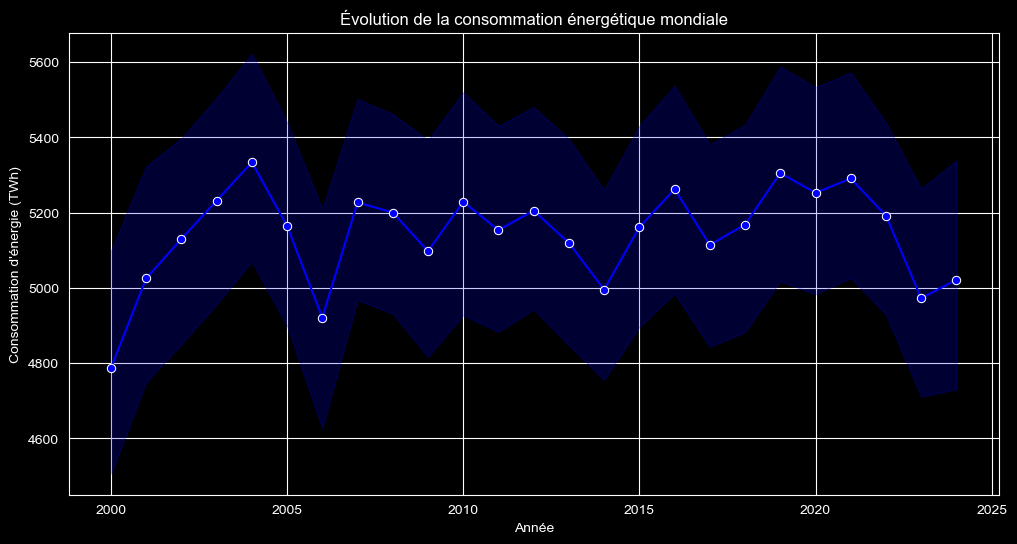

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Year'], y=df['Total_Consumption'], marker='o', color='b')
plt.xlabel("Année")
plt.ylabel("Consommation d'énergie (TWh)")
plt.title("Évolution de la consommation énergétique mondiale")
plt.grid(True)
plt.show()

- Période initiale (environ 2000-2005) : On observe une augmentation notable de la consommation
- Période de fluctuation (environ 2005-2015) : La consommation semble osciller, avec des périodes de légère augmentation et de légère diminution, mais sans tendance claire à une forte croissance ou décroissance
- Période récente (environ 2015-2024) : La consommation semble reprendre une tendance à la hausse, atteignant potentiellement un pic vers la fin de la période observée

# 2️⃣ Part des énergies dans la consommation totale

Un graphique en secteurs pour voir la répartition des sources d'énergie.

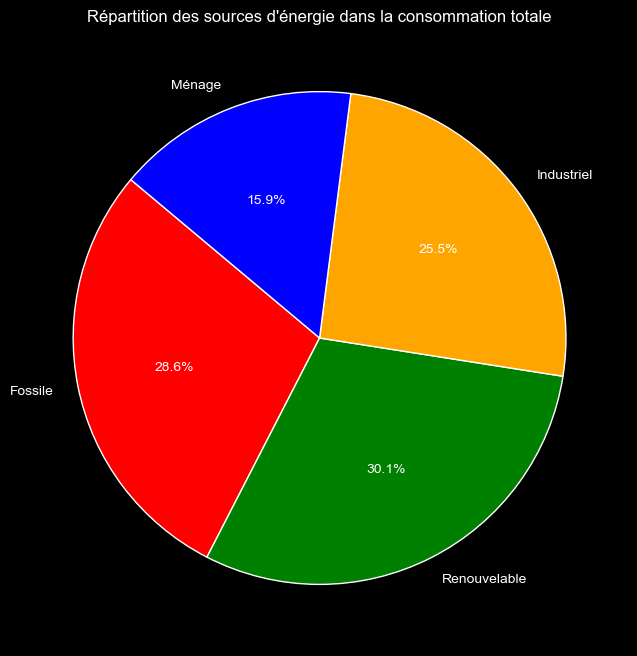

In [14]:
labels = ['Fossile', 'Renouvelable', 'Industriel', 'Ménage']
sizes = [
    df['Fossil_Fuel_Dependency'].sum(),
    df['Renewable_Share'].sum(),
    df['Industrial_Use'].sum(),
    df['Household_Use'].sum()
]
colors = ['red', 'green', 'orange', 'blue']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Répartition des sources d'énergie dans la consommation totale")
plt.show()


Ce graphique circulaire illustre la répartition des sources d'énergie dans la consommation totale après la correction du code

- Renouvelable (Vert) : Cette section représente 30.1% de la consommation totale. C'est la plus grande part, indiquant que les énergies renouvelables (comme le solaire, l'éolien, l'hydraulique, etc.) constituent la principale source d'énergie consommée.
- Fossile (Rouge) : Avec 28.6%, les combustibles fossiles (charbon, pétrole, gaz naturel) représentent la deuxième plus grande part de la consommation totale. La différence avec la part des énergies renouvelables est relativement faible.
- Industriel (Orange) : La consommation d'énergie par le secteur industriel représente 25.5% du total. C'est une part significative de la consommation globale.
- Ménage (Bleu) : La consommation d'énergie des ménages représente 15.9% du total. C'est la plus petite part des quatre catégories présentées.

Le graphique montre une répartition où les énergies renouvelables ont la part la plus importante de la consommation totale, suivies de près par les combustibles fossiles et ensuite par la consommation industrielle. La consommation des ménages représente la plus petite part. Cela suggère une transition progressive vers les énergies renouvelables, bien que les combustibles fossiles restent une source d'énergie majeure

# 3️⃣ Évolution de la consommation d’énergie fossile vs renouvelable

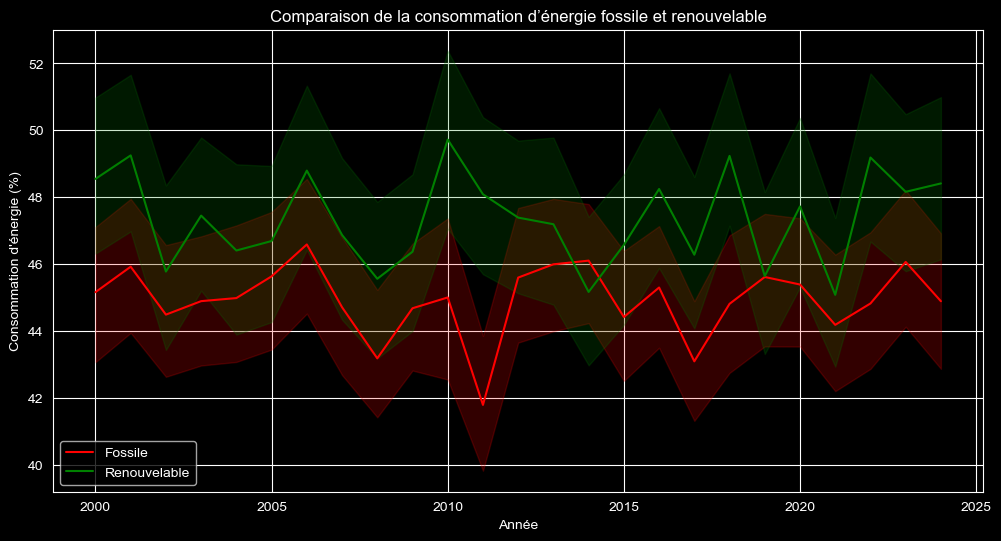

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Year'], y=df['Fossil_Fuel_Dependency'], label="Fossile", color="red")
sns.lineplot(x=df['Year'], y=df['Renewable_Share'], label="Renouvelable", color="green")
plt.xlabel("Année")
plt.ylabel("Consommation d'énergie (%)")
plt.title("Comparaison de la consommation d’énergie fossile et renouvelable")
plt.legend()
plt.grid(True)
plt.show()


Le graphique suggère que sur la période étudiée (2000 à 2024), la part des énergies renouvelables dans la consommation totale a été généralement légèrement supérieure à celle des énergies fossiles. Bien qu'il y ait des fluctuations annuelles pour les deux types d'énergie, aucune des deux ne montre une augmentation ou une diminution drastique de sa part relative sur l'ensemble de la période. On peut noter une légère convergence des deux courbes vers la fin de la période, indiquant une possible stabilisation des parts relatives.

Il est important de noter que ce graphique présente des pourcentages et non des valeurs absolues. Ainsi, même si la part relative des énergies renouvelables est légèrement supérieure, la consommation totale d'énergie (comme vu dans le premier graphique) ayant augmenté, la consommation absolue des deux types d'énergie a probablement également augmenté.

# 4️⃣Évolution du prix de l’énergie au fil du temps


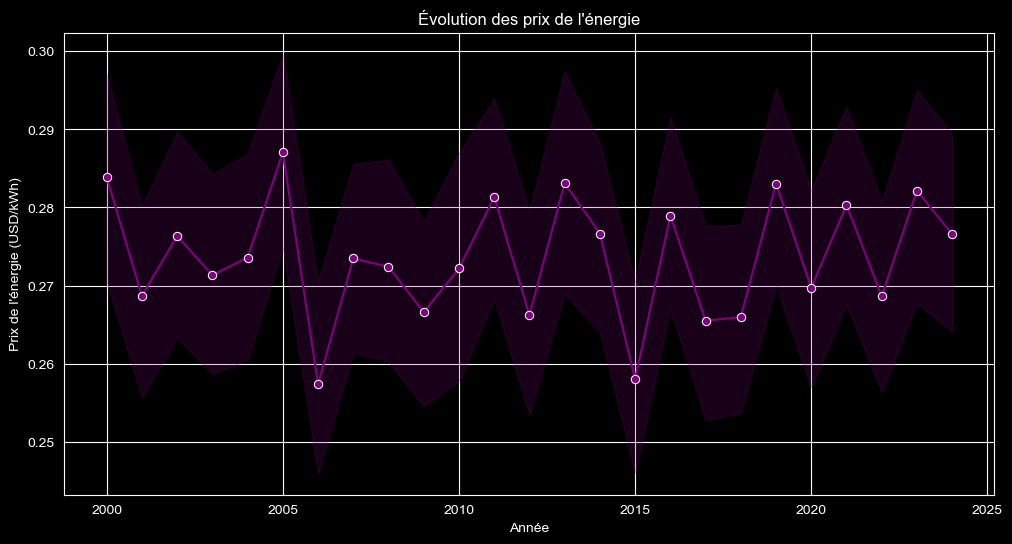

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Year'], y=df['Energy_Price_Index'], marker='o', color='purple')
plt.xlabel("Année")
plt.ylabel("Prix de l'énergie (USD/kWh)")
plt.title("Évolution des prix de l'énergie")
plt.grid(True)
plt.show()


En observant le graphique, on peut noter que le prix de l'énergie a fluctué considérablement au cours de la période étudiée. Il n'y a pas de tendance linéaire claire à une augmentation ou une diminution constante. On observe plutôt une série de hausses et de baisses :

- Période 2000-2005 : Le prix semble initialement augmenter, puis connaît une forte hausse autour de 2005.
- Période 2005-2015 : Après le pic de 2005, le prix diminue, remonte, puis fluctue de manière irrégulière
- Période 2015-2024 : La volatilité des prix semble se poursuivre, avec des pics et des creux notables.

En résumé le prix de l'énergie a été sujet à une certaine instabilité entre 2000 et 2024, avec des variations annuelles significatives. Il n'y a pas de tendance claire et uniforme à la hausse ou à la baisse sur l'ensemble de la période.

# 5️⃣ Part de l’industrie et des ménages dans la consommation énergétique

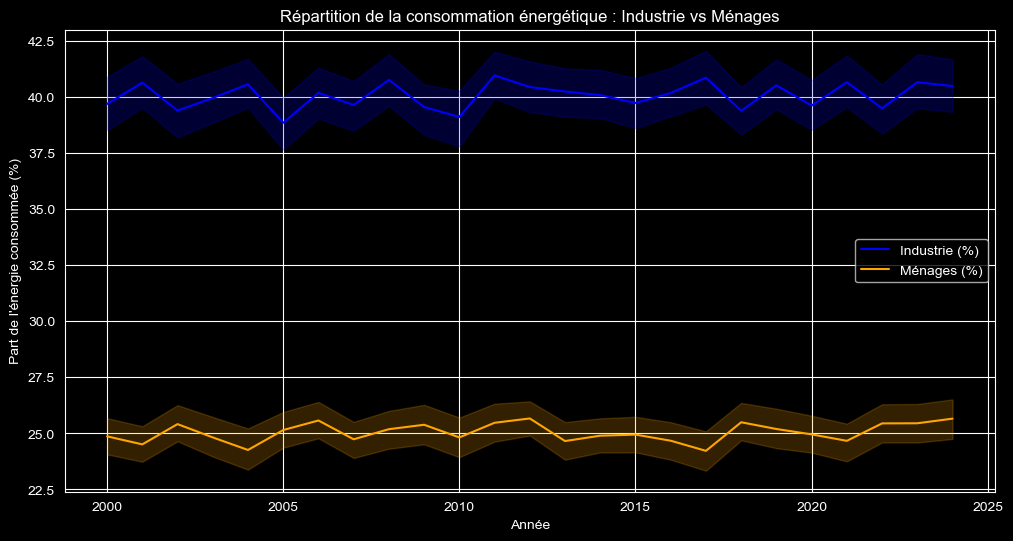

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Year'], y=df['Industrial_Use'], label="Industrie (%)", color="blue")
sns.lineplot(x=df['Year'], y=df['Household_Use'], label="Ménages (%)", color="orange")
plt.xlabel("Année")
plt.ylabel("Part de l'énergie consommée (%)")
plt.title("Répartition de la consommation énergétique : Industrie vs Ménages")
plt.legend()
plt.grid(True)
plt.show()


Le graphique montre clairement que le secteur industriel consomme une part beaucoup plus importante de l'énergie totale que les ménages sur la période de 2000 à 2024. La part de la consommation industrielle est restée relativement stable autour de 40%, tandis que la part de la consommation des ménages s'est maintenue autour de 25%. Il n'y a pas de signe de convergence ou de divergence significative entre ces deux parts au cours de cette période. Cela suggère que la structure de la consommation énergétique entre ces deux secteurs est restée relativement constante.

# 6️⃣Répartition de la consommation d’énergie par pays

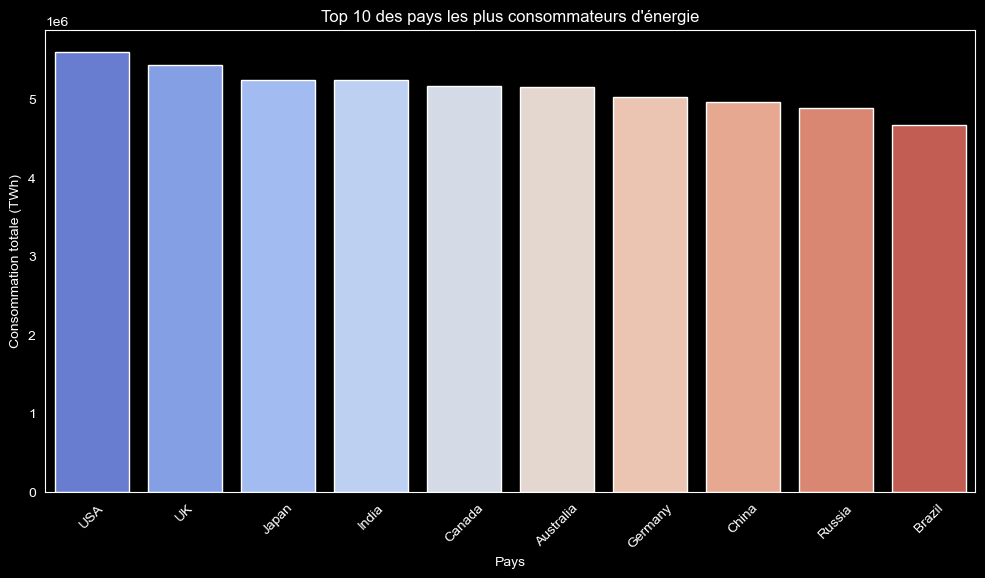

In [18]:
top_countries = df.groupby("Country")["Total_Consumption"].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette="coolwarm")
plt.xlabel("Pays")
plt.ylabel("Consommation totale (TWh)")
plt.title("Top 10 des pays les plus consommateurs d'énergie")
plt.xticks(rotation=45)
plt.show()

Ce graphique met en évidence que les États-Unis et la Chine sont les plus grands consommateurs d'énergie parmi les 10 premiers pays, suivis de près par la Russie. Le Royaume-Uni, le Japon, l'Inde et le Canada constituent le groupe suivant, tandis que l'Australie, l'Allemagne et le Brésil ont une consommation totale plus faible au sein de ce top 10. Il est important de noter que cette analyse est basée sur la somme de la consommation totale sur toute la période couverte par le dataset

# 7️⃣ Corrélation entre consommation d’énergie et émissions de CO₂

C:\Users\Gauthier Shimatu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


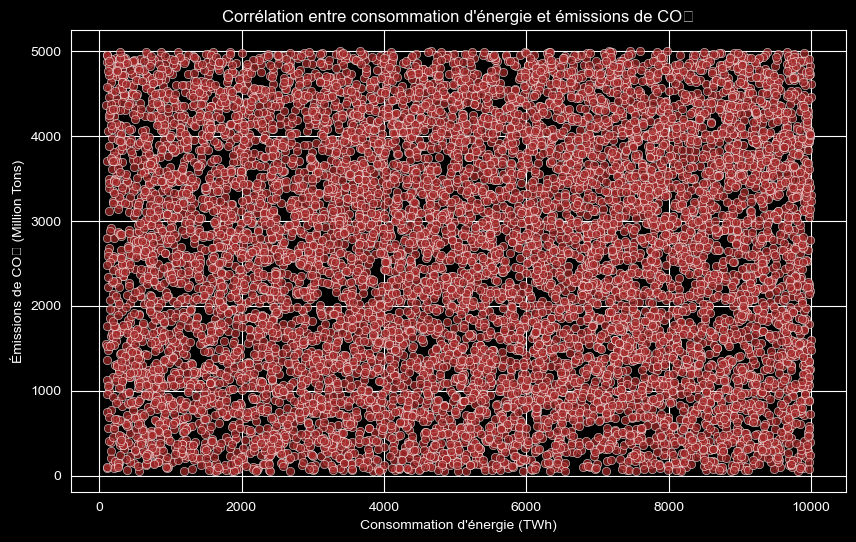

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Total_Consumption'], y=df['Carbon_Emissions'], alpha=0.7, color="brown")
plt.xlabel("Consommation d'énergie (TWh)")
plt.ylabel("Émissions de CO₂ (Million Tons)")
plt.title("Corrélation entre consommation d'énergie et émissions de CO₂")
plt.grid(True)
plt.show()

En observant la distribution des points, on peut noter une corrélation positive entre la consommation d'énergie et les émissions de CO₂. Cela signifie qu'en général, les pays ou les périodes avec une consommation d'énergie plus élevée tendent également à avoir des émissions de CO₂ plus importantes.

- Tendance : Les points semblent former une sorte de "nuage" qui s'étend du coin inférieur gauche (faible consommation, faibles émissions) vers le coin supérieur droit (forte consommation, fortes émissions). Bien qu'il y ait une dispersion, la concentration des points suggère une relation croissante entre les deux variables.
- Absence de forte linéarité : La relation n'est pas parfaitement linéaire, car on observe une certaine dispersion des points autour d'une ligne imaginaire qui pourrait traverser le nuage. Cela suggère que d'autres facteurs, tels que le mix énergétique (la part des énergies fossiles par rapport aux énergies renouvelables), peuvent influencer les émissions de CO₂ pour un niveau de consommation d'énergie donné.
- Points isolés : On pourrait potentiellement identifier quelques points qui s'écartent de la tendance générale, indiquant des cas où la relation entre la consommation d'énergie et les émissions de CO₂ pourrait être différente (par exemple, des pays avec une forte consommation mais une part importante d'énergies renouvelables pourraient se situer plus bas sur l'axe des émissions).

En resumé donc ce graphique suggère qu'il existe une relation directe entre la quantité d'énergie consommée et la quantité de CO₂ émise. Plus un pays ou une période consomme d'énergie, plus ses émissions de CO₂ ont tendance à être élevées. Cependant, la dispersion des points indique que d'autres facteurs jouent également un rôle dans la détermination des émissions.

# 8️⃣ Distribution des énergies fossiles par pays

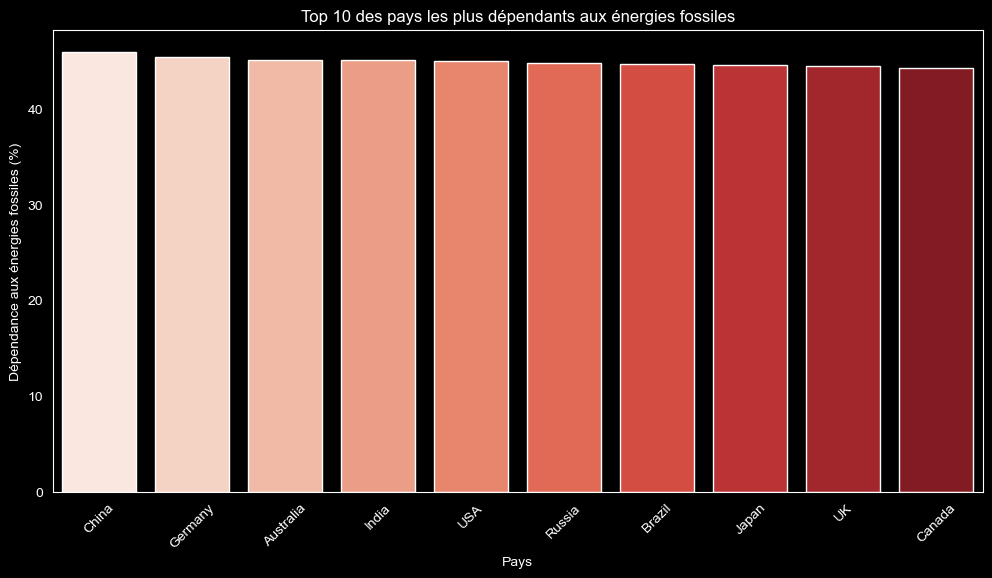

In [20]:
top_fossil = df.groupby("Country")["Fossil_Fuel_Dependency"].mean().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_fossil.index, y=top_fossil.values, palette="Reds")
plt.xlabel("Pays")
plt.ylabel("Dépendance aux énergies fossiles (%)")
plt.title("Top 10 des pays les plus dépendants aux énergies fossiles")
plt.xticks(rotation=45)
plt.show()


Ce graphique met en évidence que la Chine, l'Allemagne, l'Australie, l'Inde, les États-Unis et la Russie sont les pays les plus dépendants aux énergies fossiles parmi ce top 10. Le Brésil, le Japon, le Royaume-Uni et le Canada affichent une dépendance relativement moins élevée, bien qu'elle reste significative. Dans la période de 2000 à 2004 !

# 9️⃣ Histogramme de la consommation d’énergie par habitant

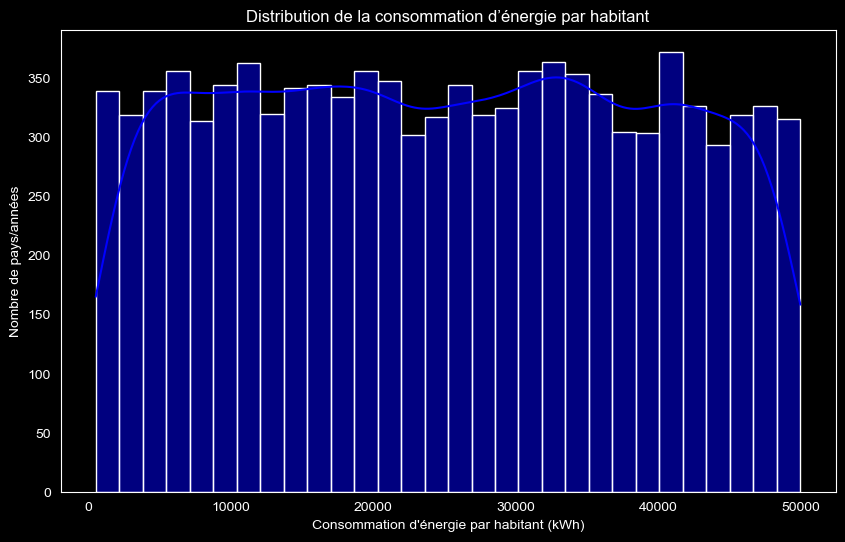

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Per_Capita_Use'], bins=30, kde=True, color="blue")
plt.xlabel("Consommation d'énergie par habitant (kWh)")
plt.ylabel("Nombre de pays/années")
plt.title("Distribution de la consommation d’énergie par habitant")
plt.show()

La distribution de la consommation d'énergie par habitant est complexe et suggère la présence de plusieurs groupes de pays/années avec des niveaux de consommation distincts. Une part importante des observations se situe dans les niveaux de consommation par habitant plus faibles, mais il existe également un nombre non négligeable de pays/années avec une consommation par habitant beaucoup plus élevée. L'analyse de cette distribution peut aider à comprendre les disparités en termes de consommation d'énergie à travers le monde et au fil du temps.

# 🔟 Évolution des émissions de carbone par pays

C:\Users\Gauthier Shimatu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


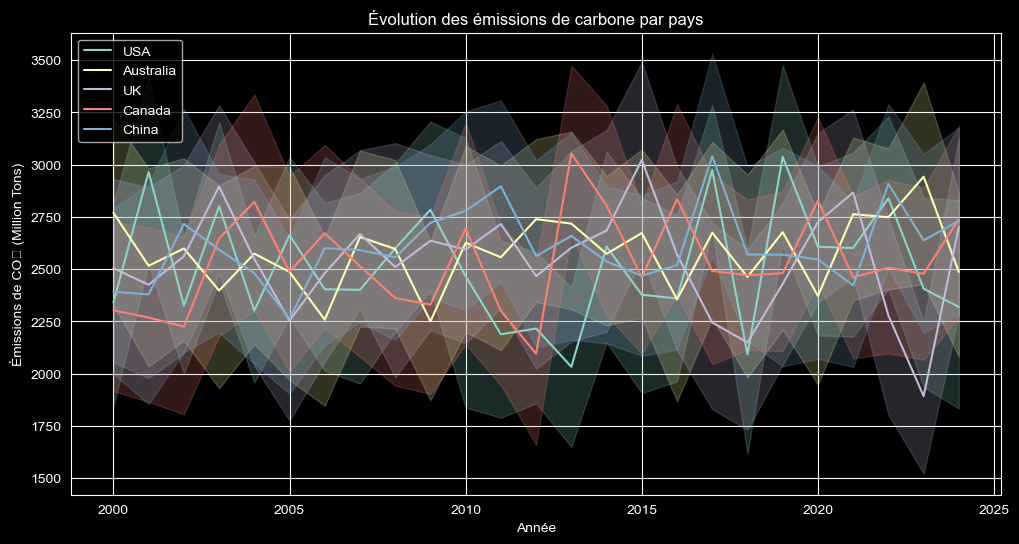

In [22]:
top_countries_co2 = df.groupby("Country")["Carbon_Emissions"].sum().nlargest(5).index

plt.figure(figsize=(12, 6))
for country in top_countries_co2:
    country_df = df[df["Country"] == country]
    sns.lineplot(x=country_df["Year"], y=country_df["Carbon_Emissions"], label=country)

plt.xlabel("Année")
plt.ylabel("Émissions de CO₂ (Million Tons)")
plt.title("Évolution des émissions de carbone par pays")
plt.legend()
plt.grid(True)
plt.show()


En observant les courbes, on peut analyser l'évolution des émissions de CO₂ pour chacun des 5 principaux émetteurs :

- Chine (Bleu clair) : La Chine montre une tendance générale à la hausse des émissions de CO₂ sur la période étudiée, avec une augmentation notable à partir du milieu des années 2000. Elle dépasse rapidement les émissions des autres pays et devient le plus grand émetteur de ce groupe
- USA (Vert foncé) : Les États-Unis affichent des émissions de CO₂ qui fluctuent, mais sans tendance claire à une augmentation ou une diminution significative sur l'ensemble de la période. Leurs émissions sont élevées mais semblent relativement stables, voire légèrement en baisse vers la fin de la période
- Canada (Rose ou Rouge) : Le Canada présente des émissions de CO₂ qui fluctuent également, mais restent généralement inférieures à celles des États-Unis et de la Chine. Il n'y a pas de tendance marquée à la hausse ou à la baisse
- UK (Gris) : Le Royaume-Uni montre une tendance à la baisse des émissions de CO₂ sur la période étudiée, particulièrement notable à partir du milieu des années 2000
- Australia (Jaune clair) : L'Australie affiche des émissions de CO₂ qui fluctuent, mais sans tendance globale claire à une forte augmentation ou diminution. Ses émissions se situent généralement entre celles du Royaume-Uni/Canada et des États-Unis

Si je peux le resumer, ce graphique met en valeur la trajectoire différente des émissions de CO₂ pour les 5 principaux émetteurs. La Chine a connu une augmentation significative de ses émissions, devenant le principal émetteur du groupe. Les États-Unis ont maintenu des émissions élevées mais relativement stables, tandis que le Royaume-Uni a réussi à réduire ses émissions. Le Canada et l'Australie montrent des fluctuations sans tendance claire à long terme sur cette période.

# 1️⃣1️⃣ Comparaison des prix de l’énergie entre pays

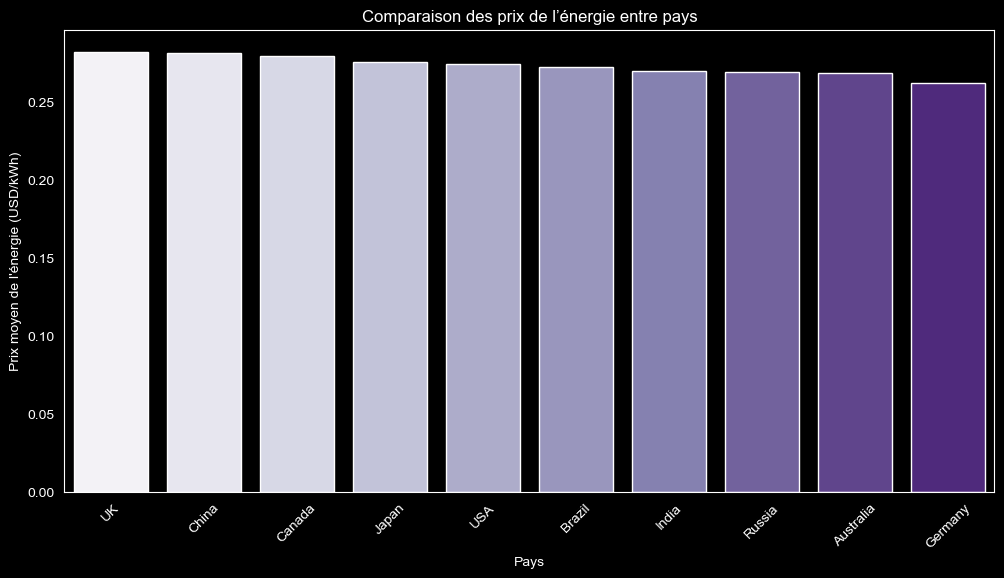

In [23]:
top_countries_prices = df.groupby("Country")["Energy_Price_Index"].mean().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries_prices.index, y=top_countries_prices.values, palette="Purples")
plt.xlabel("Pays")
plt.ylabel("Prix moyen de l'énergie (USD/kWh)")
plt.title("Comparaison des prix de l’énergie entre pays")
plt.xticks(rotation=45)
plt.show()


Le Royaume-Uni a le prix moyen le plus élevé, suivi de près par la Chine et le Canada. L'Allemagne a le prix moyen le plus bas de ce groupe. Ces différences de prix peuvent être influencées par divers facteurs tels que les sources d'énergie utilisées, les politiques gouvernementales, les coûts de production et de distribution.

# 1️⃣2️⃣ Corrélation entre prix de l’énergie et part des renouvelables

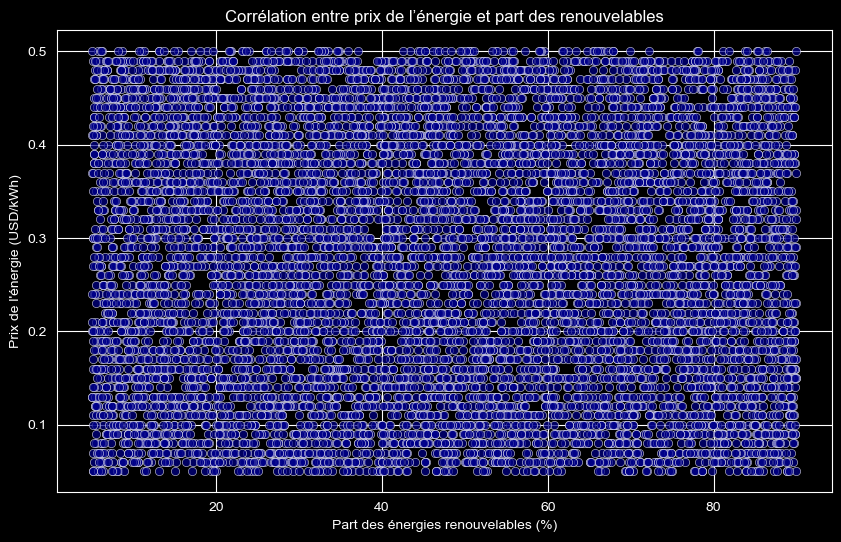

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Renewable_Share'], y=df['Energy_Price_Index'], alpha=0.7, color="darkblue")
plt.xlabel("Part des énergies renouvelables (%)")
plt.ylabel("Prix de l'énergie (USD/kWh)")
plt.title("Corrélation entre prix de l’énergie et part des renouvelables")
plt.grid(True)
plt.show()


En observant la distribution des points, il ne semble pas y avoir de corrélation forte et évidente entre la part des énergies renouvelables et le prix de l'énergie

- Absence de tendance claire : Les points sont dispersés sur l'ensemble du graphique sans former de tendance ascendante ou descendante distincte. Cela suggère qu'une part plus élevée d'énergies renouvelables dans le mix énergétique n'est pas systématiquement associée à un prix de l'énergie plus élevé ou plus bas
- Variabilité des prix pour différentes parts de renouvelables : Pour une part donnée d'énergies renouvelables, on observe une large gamme de prix de l'énergie. De même, pour une fourchette de prix donnée, on trouve des pays/années avec des parts de renouvelables variées
- Concentration des points : On peut noter une certaine concentration de points dans la partie inférieure du graphique (prix de l'énergie entre 0.1 et 0.3 USD/kWh) et sur une large plage de parts de renouvelables (de 10% à 80%).

# 1️⃣3️⃣ Analyse des outliers dans la consommation énergétique

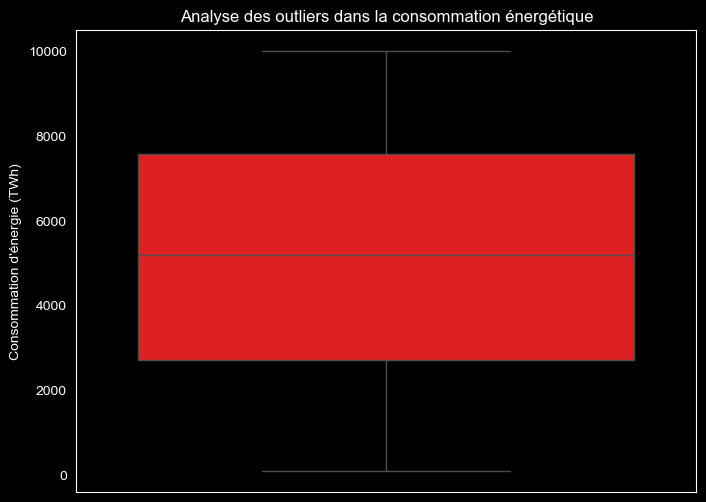

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total_Consumption'], color="red")
plt.ylabel("Consommation d'énergie (TWh)")
plt.title("Analyse des outliers dans la consommation énergétique")
plt.show()


La boîte à moustaches montre la distribution de la consommation totale d'énergie à travers le dataset. La médiane se situe autour de 5000 TWh. La majorité des données se concentrent entre environ 2700 TWh (Q1) et 7500 TWh (Q3). L'absence d'outliers distincts suggère que, bien qu'il y ait une variabilité dans la consommation totale d'énergie, il n'y a pas de valeurs extrêmement éloignées du reste de la distribution selon le critère de 1.5 fois l'IQR. Néanmoins, la longue moustache supérieure indique que certaines observations ont une consommation totale d'énergie significativement plus élevée que la majorité des données.

# Projections Futures de la Consommation Énergétique avec une régression linéaire

C:\Users\Gauthier Shimatu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


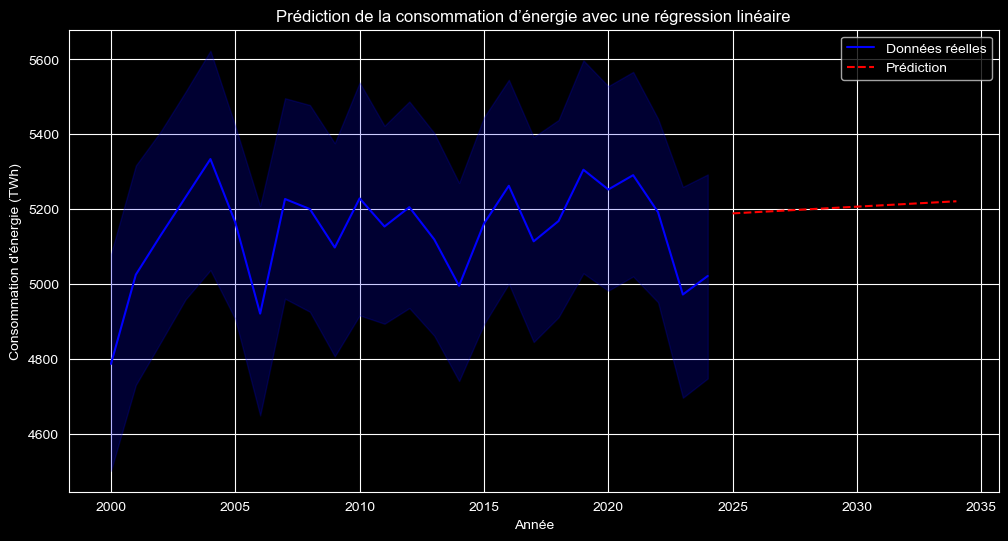

In [26]:
from sklearn.linear_model import LinearRegression

# Préparation des données
X = df[['Year']]
y = df['Total_Consumption']

# Entraînement du modèle
model = LinearRegression()
model.fit(X, y)

# Prédictions pour les prochaines années
future_years = np.array(range(2025, 2035)).reshape(-1, 1)
future_predictions = model.predict(future_years)

# Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['Year'], y=df['Total_Consumption'], label="Données réelles", color="blue")
plt.plot(future_years, future_predictions, label="Prédiction", linestyle='dashed', color="red")
plt.xlabel("Année")
plt.ylabel("Consommation d'énergie (TWh)")
plt.title("Prédiction de la consommation d’énergie avec une régression linéaire")
plt.legend()
plt.grid(True)
plt.show()


# Distribution des parts de consommation par secteur d’activité

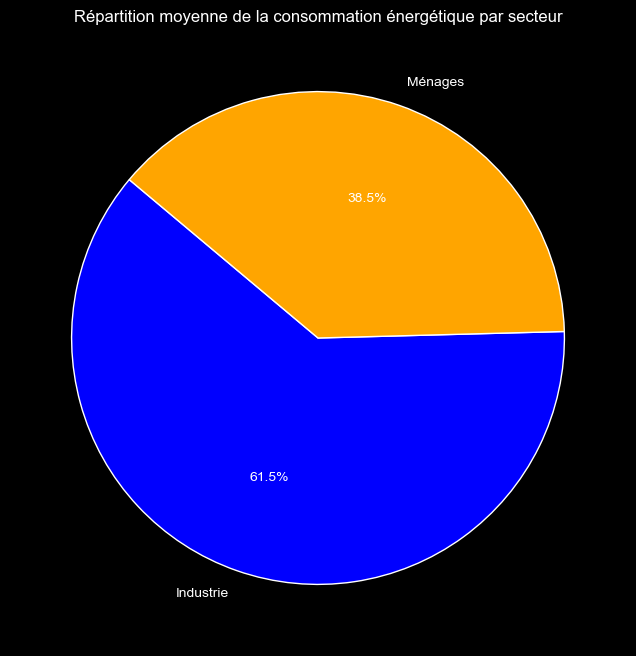

In [27]:
plt.figure(figsize=(8, 8))
labels = ['Industrie', 'Ménages']
sizes = [df['Industrial_Use'].mean(), df['Household_Use'].mean()]
colors = ['blue', 'orange']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Répartition moyenne de la consommation énergétique par secteur")
plt.show()
